<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Iksan\AppData\Local\Temp\ipykernel_23484\4147343586.py:36: SyntaxWarning: invalid escape sequence '\s'
  ax3.plot(x_data, y_val, label=r'$\mu$ = ' + str(i) + ', 1$\sigma$ = 1')  # plot tiap kurva


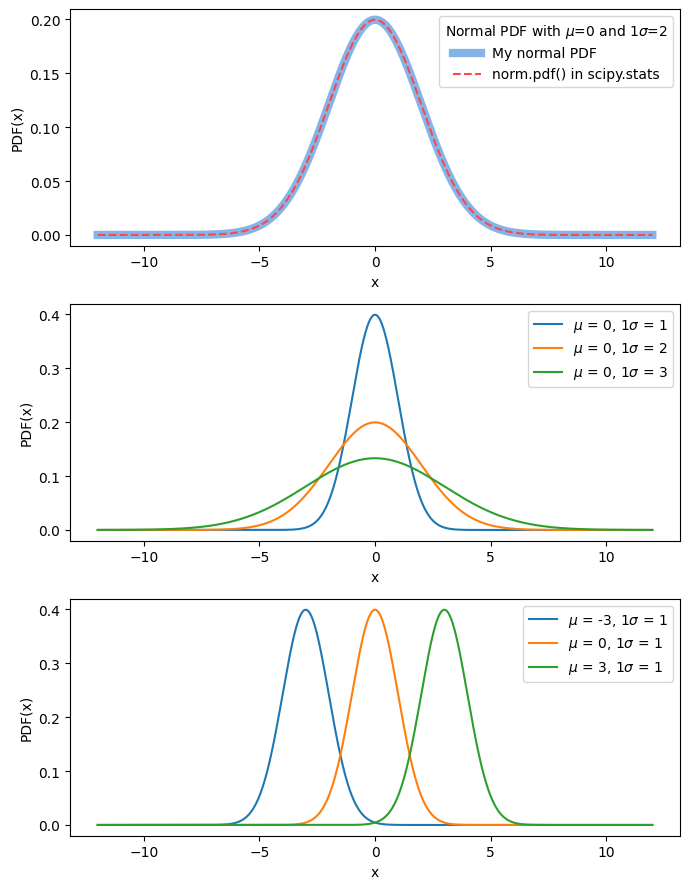

In [1]:
from scipy.stats import norm                 # import fungsi distribusi normal dari scipy
import matplotlib.pyplot as plt              # untuk membuat grafik
import numpy as np                           # untuk operasi numerik (array, matematika)

# I'm going to define my normal PDF...
def normal_pdf(x_val, mean_val, std_val):    # fungsi untuk menghitung PDF normal
    return 1/(np.sqrt(2*np.pi*std_val**2))*np.exp(-0.5*((x_val - mean_val)**2)/(std_val**2))  # rumus distribusi normal

x_data = np.arange(-12, 12, .001)            # membuat array nilai x dari -12 sampai 12 dengan step kecil

pdf1 = normal_pdf(x_data, mean_val=0, std_val=2)   # menghitung PDF buatan sendiri (mean=0, std=2)

# the built-in norm PDF in scipy.stats
pdf2 = norm.pdf(x_data, loc=0, scale=2)      # menghitung PDF menggunakan fungsi bawaan scipy

fig = plt.figure(figsize=(7,9))              # membuat figure dengan ukuran tertentu
ax1 = fig.add_subplot(3, 1, 1)               # subplot pertama (baris 1)

ax1.plot(x_data, pdf1, color='#84b4e8', linestyle="-", linewidth=6, label="My normal PDF")  # plot hasil fungsi sendiri
ax1.plot(x_data, pdf2, color='#ff464a', linestyle="--", label="norm.pdf() in scipy.stats")  # plot hasil scipy
ax1.set_xlabel("x")                          # label sumbu x
ax1.set_ylabel("PDF(x)")                     # label sumbu y
ax1.legend(title=r'Normal PDF with $\mu$=0 and 1$\sigma$=2')  # menampilkan legenda

ax2 = fig.add_subplot(3, 1, 2)               # subplot kedua (baris 2)
for i in [1, 2, 3]:                          # loop untuk variasi standar deviasi
    y_val = normal_pdf(x_data, 0, i)         # hitung PDF dengan std berbeda
    ax2.plot(x_data, y_val, label=r'$\mu$ = 0, 1$\sigma$ = ' + str(i))  # plot tiap kurva
ax2.set_xlabel("x")                          # label sumbu x
ax2.set_ylabel("PDF(x)")                     # label sumbu y
ax2.legend()                                # tampilkan legenda

ax3 = fig.add_subplot(3, 1, 3)               # subplot ketiga (baris 3)
for i in [-3, 0, 3]:                         # loop untuk variasi mean
    y_val = normal_pdf(x_data, i, 1)         # hitung PDF dengan mean berbeda
    ax3.plot(x_data, y_val, label=r'$\mu$ = ' + str(i) + ', 1$\sigma$ = 1')  # plot tiap kurva
ax3.set_xlabel("x")                          # label sumbu x
ax3.set_ylabel("PDF(x)")                     # label sumbu y
ax3.legend()                                # tampilkan legenda

fig.tight_layout()                           # merapikan layout agar tidak bertumpuk

In [2]:
from scipy.stats import norm                 # import fungsi distribusi normal (PDF)
import numpy as np                          # import numpy untuk operasi numerik
from scipy import special                   # import special function (erf)
from scipy import integrate                 # import modul integrasi numerik (API baru)

def integrate_normal(a1, a2, mean, std):    # fungsi untuk menghitung integral normal dengan erf
    sup = 0.5*(special.erf((a2-mean)/(std*np.sqrt(2))) - (special.erf((a1-mean)/(std*np.sqrt(2)))))  # rumus integral normal
    return sup                               # mengembalikan hasil integral

val_mu = 0                                   # nilai mean (rata-rata)
val_sigma = 1                                # nilai standar deviasi

val_x1 = 0                                   # batas bawah integral
val_x2 = val_sigma                           # batas atas integral

# The expected value is equal to 0.3413...
area_val = integrate_normal(a1=val_x1, a2=val_x2, mean=val_mu, std=val_sigma)  # hitung luas dengan erf

x_arr = np.arange(val_x1, val_x2, 0.0001)    # membuat array x untuk integrasi numerik
y_arr = norm.pdf(x_arr, loc=val_mu, scale=val_sigma)  # menghitung nilai PDF normal di setiap x

area_trapz = integrate.trapezoid(y_arr, x_arr)  # metode trapezoidal versi baru SciPy
area_simps = integrate.simpson(y_arr, x_arr)    # metode Simpson versi baru SciPy

print("Solution Using erf: {:.9f}".format(area_val))                          # menampilkan hasil metode erf
print("Using the trapezoidal rule, trapz: {:.10f}".format(area_trapz))        # menampilkan hasil trapezoidal
print("Using the composite Simpson rule, simps: {:.10f}".format(area_simps))  # menampilkan hasil Simpson

Solution Using erf: 0.341344746
Using the trapezoidal rule, trapz: 0.3413205476
Using the composite Simpson rule, simps: 0.3413205478


Sample mean equal to 0.0009
Sample standard deviation equal to 0.9922


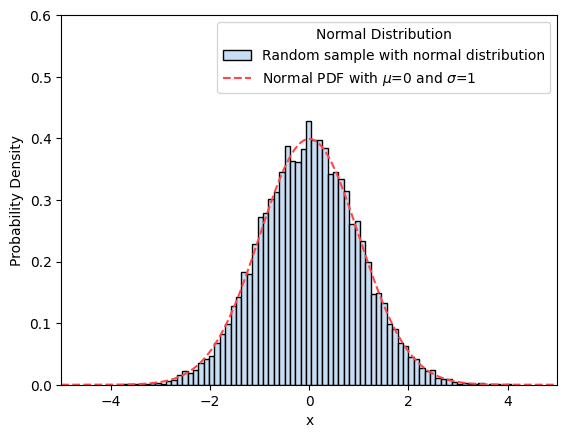

In [3]:
import numpy as np                          # import numpy untuk operasi numerik & random
from scipy.stats import norm               # import distribusi normal (PDF)
import matplotlib.pyplot as plt            # import matplotlib untuk plotting grafik

mean_val = 0                               # nilai mean (rata-rata)
std_val = 1                                # nilai standar deviasi
sample_data = np.random.normal(mean_val, std_val, 15000)  # membuat 15000 data acak normal

# plot the histogram of the sample distribution
fig, ax = plt.subplots()                   # membuat figure dan axis untuk plot
ax.hist(sample_data, bins='auto', density=True, color='#c7ddf4', edgecolor='#000000', label='Random sample with normal distribution')  # histogram data sampel

# probability density function
x_axis = np.arange(-5, 5, 0.01)            # membuat array x untuk kurva PDF
pdf_norm = norm.pdf(x_axis, loc=mean_val, scale=std_val)  # menghitung nilai PDF normal
ax.plot(x_axis, pdf_norm, color='#ff464a', linewidth=1.5, linestyle='--', label=r'Normal PDF with $\mu$=0 and $\sigma$=1')  # plot kurva PDF

ax.legend(title='Normal Distribution')     # menampilkan legenda grafik
ax.set_xlabel('x')                        # memberi label sumbu x
ax.set_ylabel('Probability Density')      # memberi label sumbu y
ax.set_xlim(-5, 5)                        # mengatur batas sumbu x
ax.set_ylim(0, 0.6)                       # mengatur batas sumbu y

# Descriptive statistics
mean_sample = sample_data.mean()          # menghitung rata-rata sampel
std_sample = sample_data.std()            # menghitung standar deviasi sampel

print('Sample mean equal to {:.4f}'.format(mean_sample))           # menampilkan rata-rata sampel
print('Sample standard deviation equal to {:.4f}'.format(std_sample))  # menampilkan standar deviasi sampel

Expected mean: 0 - Calculated mean: 0.003
Expected std.dev.: 0.5 - Calculated std.dev.: 0.499
Expected mean: 0.5 - Calculated mean: 0.499
Expected std.dev.: 0.4 - Calculated std.dev.: 0.4
Expected mean: 1 - Calculated mean: 0.999
Expected std.dev.: 0.3 - Calculated std.dev.: 0.3


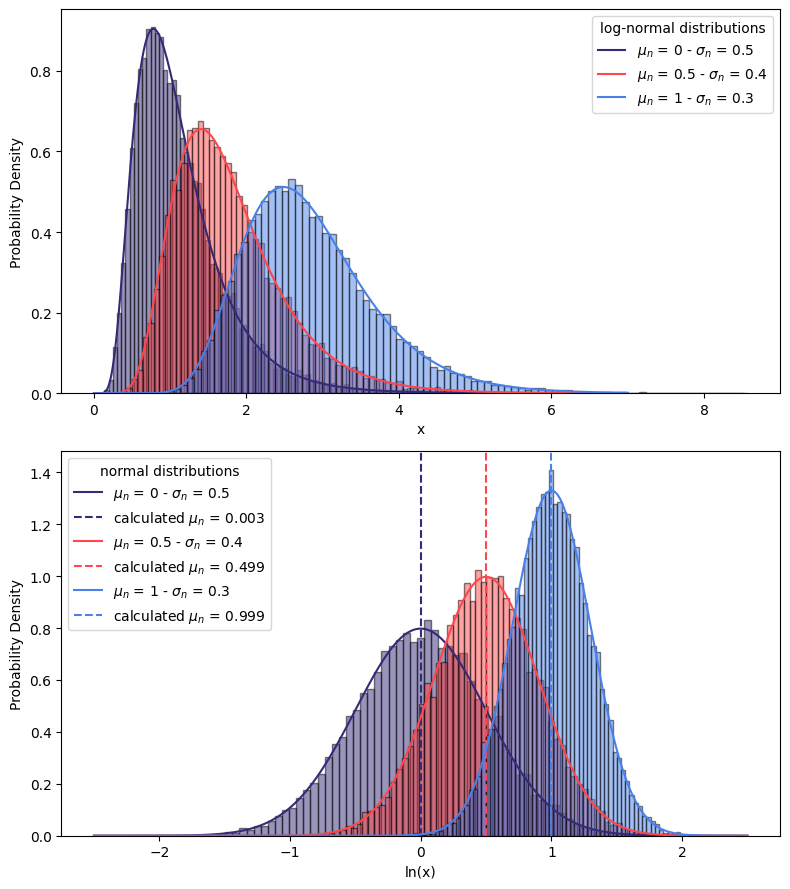

In [4]:
import matplotlib.pyplot as plt                      # import matplotlib untuk plotting
import numpy as np                                   # import numpy untuk numerik
from scipy.stats import norm, lognorm                # import distribusi normal & log-normal

color_list = ['#342a77', '#ff464a', '#4881e9']      # daftar warna HEX valid (6 digit)
mu_list = [0, 0.5, 1]                                # daftar nilai mean (mu)
sigma_list = [0.5, 0.4, 0.3]                         # daftar nilai standar deviasi (sigma)

x_vals = np.arange(0.001, 7, .001)                  # sumbu x untuk PDF log-normal
x_vals1 = np.arange(-2.5, 2.5, .001)                # sumbu x untuk PDF normal

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8,9))  # membuat 2 subplot

for mu_n, sigma_n, color in zip(mu_list, sigma_list, color_list):  # looping parameter
    lognorm_pdf = lognorm.pdf(x_vals, s=sigma_n, scale=np.exp(mu_n))  # hitung PDF log-normal
    rand_data = lognorm.rvs(s=sigma_n, scale=np.exp(mu_n), size=15000)  # generate sampel acak
    ax1.plot(x_vals, lognorm_pdf, color=color, label=r'$\mu_n$ = ' + str(mu_n) + r' - $\sigma_n$ = ' + str(sigma_n))  # plot PDF
    ax1.hist(rand_data, bins='auto', density=True, color=color, edgecolor='#000000', alpha=0.5)  # histogram sampel

    log_r = np.log(rand_data)                        # transformasi log data
    normal_pdf = norm.pdf(x_vals1, loc=mu_n, scale=sigma_n)  # hitung PDF normal
    ax2.plot(x_vals1, normal_pdf, color=color, label=r'$\mu_n$ = ' + str(mu_n) + r' - $\sigma_n$ = ' + str(sigma_n))  # plot PDF normal
    ax2.hist(log_r, bins='auto', density=True, color=color, edgecolor='#000000', alpha=0.5)  # histogram log data

    calc_mu = log_r.mean()                          # hitung mean hasil log
    ax2.axvline(x=calc_mu, color=color, linestyle='--', label=r'calculated $\mu_n$ = ' + str(round(calc_mu,3)))  # garis mean

    calc_sigma = log_r.std()                        # hitung standar deviasi hasil log
    print("Expected mean:", mu_n, "- Calculated mean:", round(calc_mu,3))  # tampilkan mean
    print("Expected std.dev.:", sigma_n, "- Calculated std.dev.:", round(calc_sigma,3))  # tampilkan std

ax1.legend(title='log-normal distributions')        # legenda subplot atas
ax1.set_xlabel('x')                                # label sumbu x atas
ax1.set_ylabel('Probability Density')              # label sumbu y atas

ax2.legend(title='normal distributions')           # legenda subplot bawah
ax2.set_xlabel('ln(x)')                           # label sumbu x bawah
ax2.set_ylabel('Probability Density')             # label sumbu y bawah

fig.tight_layout()                                # merapikan layout
plt.show()                                        # menampilkan grafik

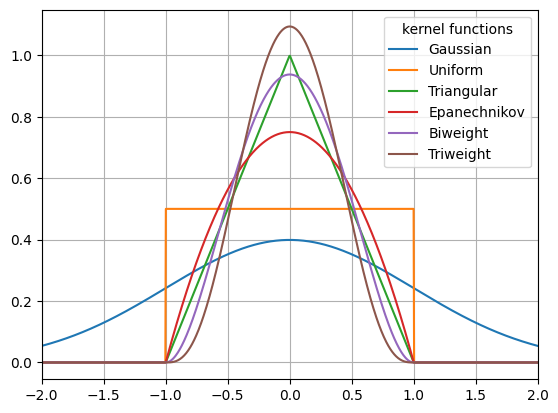

In [5]:
import numpy as np                  # berguna untuk operasi matematika dan array numerik
import matplotlib.pyplot as plt     # berguna untuk membuat grafik atau visualisasi data


x = np.linspace(-2, 2, 1000)    # berguna untuk membuat 1000 titik data dari -2 sampai 2

# definisi kernel manual
kernels = {
    "Gaussian": lambda x: (1/np.sqrt(2*np.pi))*np.exp(-0.5*x**2),               # berguna untuk membuat kernel Gaussian
    "Uniform": lambda x: np.where(abs(x) <= 1, 0.5, 0),                         # berguna untuk membuat kernel Uniform
    "Triangular": lambda x: np.where(abs(x) <= 1, 1 - abs(x), 0),               # berguna untuk membuat kernel Triangular
    "Epanechnikov": lambda x: np.where(abs(x) <= 1, 0.75*(1 - x**2), 0),        # berguna untuk membuat kernel Epanechnikov
    "Biweight": lambda x: np.where(abs(x) <= 1, (15/16)*(1 - x**2)**2, 0),      # berguna untuk membuat kernel Biweight
    "Triweight": lambda x: np.where(abs(x) <= 1, (35/32)*(1 - x**2)**3, 0)      # berguna untuk membuat kernel Triweight
}

fig, ax = plt.subplots()    # berguna untuk membuat figure dan area plot

for name, func in kernels.items():      # berguna untuk mengambil nama dan fungsi kernel satu per satu
    y = func(x)                         # berguna untuk menghitung nilai y dari fungsi kernel
    ax.plot(x, y, label=name, linewidth=1.5)    # berguna untuk menampilkan grafik kernel

ax.set_xlim(-2, 2)  # berguna untuk mengatur batas sumbu x dari -2 sampai 2
ax.grid()           # berguna untuk menampilkan garis grid pada grafik
ax.legend(title='kernel functions') # berguna untuk menampilkan legenda grafik


plt.show()   # berguna untuk menampilkan hasil grafik

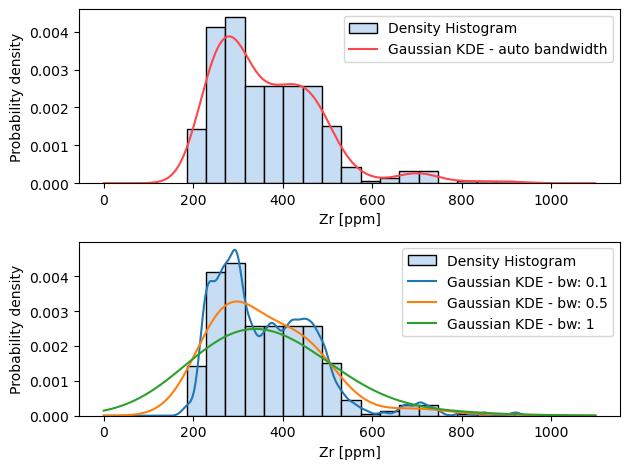

In [ ]:
import pandas as pd         # berguna untuk membaca dan mengolah data (terutama Excel)
import numpy as np          # berguna untuk operasi numerik dan array
import matplotlib.pyplot as plt         # berguna untuk membuat grafik/plot
from scipy.stats import gaussian_kde    # berguna untuk menghitung Kernel Density Estimation (KDE)

# baca data
my_dataset = pd.read_excel(r'C:\Users\Iksan\python_earth_science_book-main\code\chapter_09\Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')    # membaca file Excel dan sheet tertentu

x = my_dataset["Zr"].dropna()       # mengambil kolom "Zr" dan menghapus nilai kosong (NaN)
x_eval = np.arange(0, 1100, 1)      # membuat array nilai dari 0 sampai 1100 untuk evaluasi grafik

fig = plt.figure()                  # membuat objek figure untuk plot

# ===== subplot 1 =====
ax1 = fig.add_subplot(2, 1, 1)      # membuat subplot pertama (2 baris, 1 kolom, posisi ke-1)

# histogram
ax1.hist(x, bins='auto', density=True,              # membuat histogram dengan normalisasi (density)
         label='Density Histogram',                 # memberi label histogram
         color='#c7ddf4', edgecolor='#000000')  # mengatur warna isi dan garis tepi

# KDE otomatis
kde = gaussian_kde(x)           # menghitung KDE dari data x
my_kde = kde(x_eval)            # mengevaluasi KDE pada nilai x_eval

ax1.plot(x_eval, my_kde,             # plot kurva KDE
         linewidth=1.5,              # mengatur ketebalan garis
         color='#ff464a',          # mengatur warna garis
         label='Gaussian KDE - auto bandwidth')  # memberi label garis KDE


ax1.set_xlabel('Zr [ppm]')              # memberi label sumbu x
ax1.set_ylabel('Probability density')   # memberi label sumbu y
ax1.legend()                            # menampilkan legenda


# ===== subplot 2 =====
ax2 = fig.add_subplot(2, 1, 2)          # membuat subplot kedua

# histogram
ax2.hist(x, bins='auto', density=True,  # membuat histogram kedua
         label='Density Histogram',     # label histogram
         color='#c7ddf4', edgecolor='#000000') # warna histogram

    
for my_bw in [0.1, 0.5, 1]:     # melakukan loop untuk beberapa nilai bandwidth
    kde = gaussian_kde(x, bw_method=my_bw)  # menghitung KDE dengan bandwidth tertentu
    my_kde = kde(x_eval)        # evaluasi KDE

    ax2.plot(x_eval, my_kde,    # plot hasil KDE
             linewidth=1.5,     # ketebalan garis
             label=f'Gaussian KDE - bw: {my_bw}')  # label sesuai nilai bandwidth


ax2.set_xlabel('Zr [ppm]')               # label sumbu x
ax2.set_ylabel('Probability density')    # label sumbu y
ax2.legend()                             # menampilkan legenda

fig.tight_layout()             # mengatur layout agar rapi
plt.show()                     # menampilkan grafik

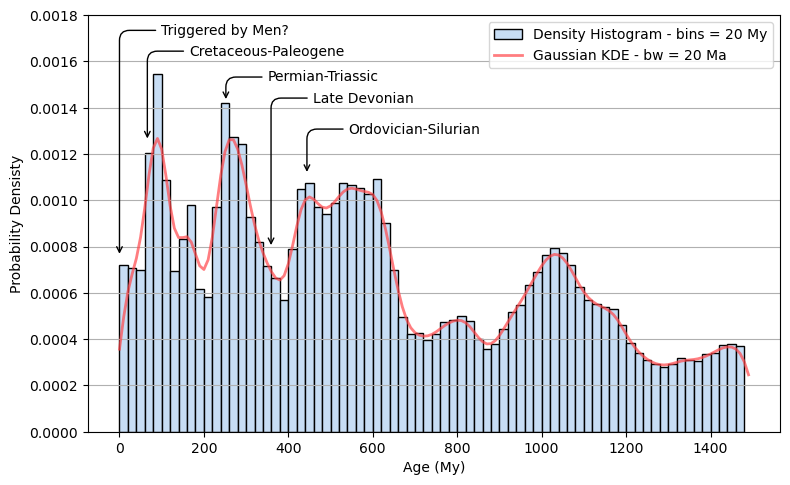

In [ ]:
import pandas as pd                 # untuk mengolah dan membaca data berbentuk tabel (excel/csv)
import matplotlib.pyplot as plt    # untuk membuat grafik/plot
import numpy as np                 # untuk perhitungan numerik dan array
from statsmodels.nonparametric.kde import KDEUnivariate  # untuk membuat kurva KDE (kepadatan distribusi)

# import Zircon data from Puetz (2010)
my_data = pd.read_excel("C:/Users/ikyan/python_earth_science/book_main/code/chapter_09/1-s2.0-S1674987117302141-mmc1.xlsx", sheet_name="Data")  # membaca file excel
my_data = my_data[(my_data.age20Pb_238U > 0) & (my_data.age20Pb_238U < 1500)]  # memfilter data umur antara 0 dan 1500
my_sample = my_data.age20Pb_238U    # mengambil kolom umur sebagai sampel data

# Plot the Density Histogram
fig, ax = plt.subplots(figsize=(8,5))   # membuat area figure dan axis untuk plot
bins = np.arange(0,1500,20)            # membuat interval bin dari 0–1500 dengan lebar 20
ax.hist(my_sample, bins, color='#c7ddf4', edgecolor='k', density=True, label='Density Histogram - bins = 20 My')  # membuat histogram density

# Compute and plot the KDE
age_eval = np.arange(0,1500,10)     # titik evaluasi kurva KDE setiap 10 satuan
kde = KDEUnivariate(my_sample)     # membuat objek KDE dari data sampel
kde.fit(bw=20)                     # melakukan fitting KDE dengan bandwidth 20
pdf = kde.evaluate(age_eval)       # menghitung nilai kepadatan pada titik evaluasi
ax.plot(age_eval, pdf, label='Gaussian KDE - BW = 20 Ma', linewidth=2, alpha=0.7, color='#ff464a')  # menampilkan kurva KDE

# Adjust diagram parameters
ax.set_ylim(0,0.0018)              # mengatur batas sumbu Y
ax.set_xlabel('Age (My)')          # memberi label sumbu X
ax.set_ylabel('Probability Density')  # memberi label sumbu Y
ax.legend()                        # menampilkan legenda
ax.grid(axis='y')                  # menampilkan garis grid pada sumbu Y

# Plot mass extinction annotations
mass_extinction_age = [444, 359, 252, 66, 0]   # daftar umur kejadian kepunahan massal
pdf_mass_extinction_age = kde.evaluate(mass_extinction_age)  # mencari nilai density di umur tersebut
mass_extinction_name = ["Ordovician-Silurian", "Late Devonian", "Permian-Triassic", "Cretaceous-Paleogene", "Triggered by Men?"]  # nama kejadian
y_offsets = [0.0001, 0.0001, 0.0002, 0.0002, 0.0004]  # jarak tambahan di sumbu Y untuk teks
y_texts = [30, 105, 15, 62, 160]  # posisi teks di sumbu Y
x_texts = [30, 30, 30, 30, 30]    # posisi teks di sumbu X

for name, x, y_text, y_offset in zip(mass_extinction_name, mass_extinction_age, y_texts, y_offsets):  # perulangan untuk anotasi
    ax.annotate(name, xy=(x, y_offset), xycoords='data',   # memberi anotasi nama di titik tertentu
                xytext=(x, y_text), textcoords='offset points',  # posisi teks terhadap titik
                arrowprops=dict(arrowstyle="->",             # membuat panah penunjuk
                connectionstyle="angle,angleA=0,angleB=90,rad=10"))  # gaya koneksi panah

fig.tight_layout()   # merapikan tata letak agar tidak saling tumpang tindih

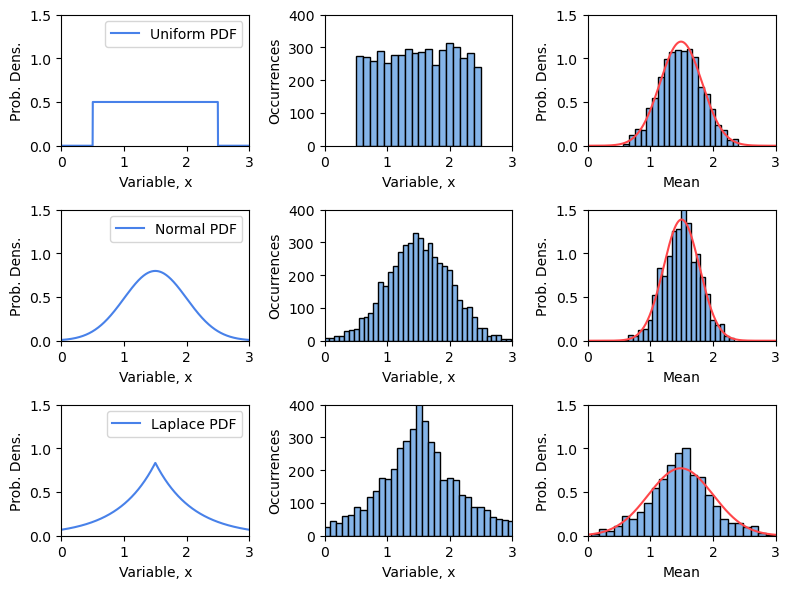

In [9]:
import numpy as np  #berfungsi untuk melakukan perhitungan numerik dan array
import scipy.stats as stats  #berfungsi untuk analisis statistik dan distribusi probabilitas
import matplotlib.pyplot as plt  #berfungsi untuk membuat grafik dan visualisasi

fig = plt.figure(figsize=(8,6))  #berfungsi untuk membuat kanvas grafik berukuran 8x6

dists = [stats.uniform(loc=0.5, scale=2), stats.norm(loc=1.5, scale=0.5), stats.laplace(loc=1.5, scale=0.6)]  
#berfungsi untuk membuat daftar distribusi probabilitas

names = ['Uniform', 'Normal', 'Laplace']  #berfungsi untuk menyimpan nama distribusi

x = np.linspace(0,3,1000)  #berfungsi untuk membuat 1000 nilai x dari 0 sampai 3

for i, (dist, name) in enumerate(zip(dists, names)):  #berfungsi untuk melakukan perulangan pada distribusi dan namanya
    
    # Probability Density Function (pdf)

    pdf = dist.pdf(x)  #berfungsi untuk menghitung nilai PDF distribusi

    ax1 = fig.add_subplot(3, 3, 3*i+1)  #berfungsi untuk membuat subplot PDF

    ax1.plot(x, pdf, color='#4881e9', label= name + ' PDF')  
    #berfungsi untuk menggambar grafik PDF

    ax1.set_xlim(0,3)  #berfungsi untuk mengatur batas sumbu X
    ax1.set_ylim(0,1.5)  #berfungsi untuk mengatur batas sumbu Y
    ax1.set_xlabel('Variable, x')  #berfungsi untuk memberi label sumbu X
    ax1.set_ylabel('Prob. Dens.')  #berfungsi untuk memberi label sumbu Y
    ax1.legend()  #berfungsi untuk menampilkan legenda grafik
    
    #Distribution (rnd) of the Random Variable based on the selected pdf

    rnd = dist.rvs(size=5000)  #berfungsi untuk membuat 5000 data acak dari distribusi

    ax2 = fig.add_subplot(3, 3, 3*i+2)  #berfungsi untuk membuat subplot histogram data acak

    ax2.hist(rnd, bins='auto', color='#84b4e8', edgecolor='#000000')  
    #berfungsi untuk membuat histogram data acak

    ax2.set_xlim(0,3)  #berfungsi untuk mengatur batas sumbu X
    ax2.set_ylim(0,400)  #berfungsi untuk mengatur batas sumbu Y
    ax2.set_xlabel('Variable, x')  #berfungsi untuk memberi label sumbu X
    ax2.set_ylabel('Occurrences')  #berfungsi untuk memberi label sumbu Y
    
    ax3 = fig.add_subplot(3, 3, 3*i+3)  #berfungsi untuk membuat subplot distribusi rata-rata

    mean_dist = []  #berfungsi untuk menyimpan nilai rata-rata sampel

    for _ in range(1000):  #berfungsi untuk melakukan perulangan sebanyak 1000 kali
        mean_dist.append(dist.rvs(size=3).mean())  
        #berfungsi untuk mengambil 3 data acak lalu menghitung rata-ratanya

    mean_dist = np.array(mean_dist)  #berfungsi untuk mengubah list menjadi array numpy

    ax3.hist(mean_dist, density=True, bins='auto', color='#84b4e8', edgecolor='#000000')  
    #berfungsi untuk membuat histogram distribusi rata-rata

    normal = stats.norm(loc=mean_dist.mean(), scale=mean_dist.std())  
    #berfungsi untuk membuat distribusi normal berdasarkan mean dan standar deviasi data

    ax3.plot(x, normal.pdf(x), color='#ff464a')  
    #berfungsi untuk menggambar kurva distribusi normal

    ax3.set_xlim(0,3)  #berfungsi untuk mengatur batas sumbu X
    ax3.set_ylim(0,1.5)  #berfungsi untuk mengatur batas sumbu Y
    ax3.set_xlabel('Mean')  #berfungsi untuk memberi label sumbu X
    ax3.set_ylabel('Prob. Dens.')  #berfungsi untuk memberi label sumbu Y
    
fig.tight_layout()  #berfungsi untuk merapikan jarak antar subplot